In [1]:
# STANDIN A0
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-For-Cybersecurity-Lab-4.2-Robustness-attacks


train 267,984 rows   attack rate 0.1507
val    89,328 rows   attack rate 0.1507
test   89,329 rows   attack rate 0.1507


68 features: 58 continuous, 10 flag columns
Flag columns: Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count
  tree    loaded from models/tree.joblib
  logreg  loaded from models/logreg.joblib


  forest  loaded from models/forest.joblib


ATTACK_IDX: 50 detected attacks, forest probability 1.000-1.000
  attack types: {'DDoS': 25, 'DoS Hulk': 22, 'DoS GoldenEye': 2, 'SSH-Patator': 1}
EXPLAIN_IDX: 500 random test flows, 68 of them attacks
Setup complete: 20 shared names ready. The models are scored in step A2.


In [2]:
# STANDIN B1
# --- copy of step B1's add_noise cell (Track 1), so this notebook runs on its own ---
import matplotlib.pyplot as plt

# Columns that are never negative in the training data: clipping these at zero only removes
# impossible values that the noise created (a negative packet count). Columns that are already
# negative in real data (-1 = "not recorded") are left alone, so clipping never edits a real value.
NONNEG_COLS = [c for c in CONT_COLS if X_train[c].min() >= 0]


def add_noise(X, X_ref, level, seed=SEED, clip=True):
    """Noisy copy of X: Gaussian noise of width level * std(X_ref) on every continuous column.

    X_ref must be the training set (std measured there, never on the data being scored).
    The 0/1 flag columns are not touched. With clip=True, columns that are never negative in
    X_ref are clipped at zero after the noise is added.
    """
    noisy = X.copy()
    if level == 0:
        return noisy
    rng = np.random.default_rng(seed)
    std = X_ref[CONT_COLS].std().to_numpy()
    values = noisy[CONT_COLS].to_numpy(dtype=float)
    values += rng.standard_normal(values.shape) * (level * std)
    if clip:
        nonneg = np.isin(CONT_COLS, [c for c in CONT_COLS if X_ref[c].min() >= 0])
        values[:, nonneg] = np.maximum(values[:, nonneg], 0.0)
    noisy[CONT_COLS] = values
    return noisy


# Sanity checks: flags untouched, level 0 changes nothing, clipped columns never negative.
_check = add_noise(X_test.iloc[:1000], X_train, 0.5)
assert _check[FLAG_COLS].equals(X_test.iloc[:1000][FLAG_COLS])
assert add_noise(X_test.iloc[:1000], X_train, 0.0).equals(X_test.iloc[:1000])
assert (_check[NONNEG_COLS] >= 0).all().all()
print(f"{len(NONNEG_COLS)} of {len(CONT_COLS)} continuous columns are clipped at zero")

47 of 58 continuous columns are clipped at zero


<!-- STEP D2 -->
### Step D2: Is the explanation stable under noise?

**Stable** means: run the explainer on almost the same input and get almost the same answer. We
explain the same 200 test flows (the first 200 of `EXPLAIN_IDX`, a subset of D1's 500) twice with
TreeSHAP, once clean and once with B1's 5% noise. For each run we rank the features by mean |SHAP|
for the attack class, and compare the two rankings with the **Spearman rank correlation** (1 = same
order, 0 = unrelated). Above 0.90 counts as stable.

Stable is not the same as *faithful* (lab section 3.5): an explanation can be perfectly stable and
still describe the wrong thing. Part F tests faithfulness.

B1 showed that 5% noise already makes the forest call almost every attack benign, so we also run two
much smaller levels (0.1% and 1%) for context. They let us tell apart "SHAP is unstable" from "the
model itself decided differently".

In [3]:
# STEP D2
import shap
from scipy.stats import spearmanr

d2_flows = X_test.iloc[EXPLAIN_IDX[:200]]
d2_y = y_test.iloc[EXPLAIN_IDX[:200]]
d2_explainer = shap.TreeExplainer(rf)


def attack_shap(X):
    """SHAP values for the attack class: one row per flow, one column per feature."""
    return d2_explainer(X).values[:, :, 1]


def ranking(values, rows=None):
    """Mean |SHAP| per feature over the given rows (all rows by default)."""
    v = values if rows is None else values[rows]
    return pd.Series(np.abs(v).mean(axis=0), index=FEATURES)


start = time.time()
d2_levels = [0.001, 0.01, 0.05]
shap_clean = attack_shap(d2_flows)
shap_noisy = {level: attack_shap(add_noise(d2_flows, X_train, level)) for level in d2_levels}
rank_clean = ranking(shap_clean)
d2_rankings = {level: ranking(v) for level, v in shap_noisy.items()}
print(f"{len(d2_flows)} flows ({int(d2_y.sum())} attacks), SHAP 4 times in {time.time() - start:.0f} s")

200 flows (24 attacks), SHAP 4 times in 221 s


In [4]:
# STEP D2
rows = []
pred_clean = rf.predict(d2_flows)
for level, rank_noisy in d2_rankings.items():
    rho, _ = spearmanr(rank_clean, rank_noisy)
    top10_overlap = len(set(rank_clean.nlargest(10).index) & set(rank_noisy.nlargest(10).index))
    pred_noisy = rf.predict(add_noise(d2_flows, X_train, level))
    rows.append({"noise level": level, "spearman": rho, "top-10 overlap": top10_overlap,
                 "top-5 identical": list(rank_clean.nlargest(5).index) == list(rank_noisy.nlargest(5).index),
                 "flows whose prediction changed": int((pred_clean != pred_noisy).sum()),
                 "attacks still detected": f"{int(pred_noisy[d2_y.to_numpy() == 1].sum())} of {int(d2_y.sum())}"})
d2_summary = pd.DataFrame(rows).set_index("noise level")
d2_summary.to_csv("results/tables/D2_stability_by_level.csv", float_format="%.4f")
d2_summary.round(4)

,spearman,top-10 overlap,top-5 identical,flows whose prediction changed,attacks still detected
noise level,,,,,
0.001,0.9071,9,False,5,19 of 24
0.010,0.9048,7,False,19,5 of 24
0.050,0.8991,7,False,23,1 of 24


In [5]:
# STEP D2
# The lab's comparison: clean vs 5% noise, both top-5 lists and the full rankings.
rank_noisy5 = d2_rankings[0.05]
rho5, _ = spearmanr(rank_clean, rank_noisy5)
print(f"Spearman rank correlation, clean vs 5% noise: {rho5:.3f}  "
      f"({'stable' if rho5 > 0.90 else 'NOT stable'} by the lab's 0.90 rule)\n")
top5 = pd.DataFrame({"clean": rank_clean.nlargest(5).index,
                     "5% noise": rank_noisy5.nlargest(5).index}, index=range(1, 6))
print(top5.to_string())

d2_table = pd.DataFrame({
    "mean_abs_shap_clean": rank_clean, "mean_abs_shap_noisy5": rank_noisy5,
    "rank_clean": rank_clean.rank(ascending=False).astype(int),
    "rank_noisy5": rank_noisy5.rank(ascending=False).astype(int),
}).sort_values("rank_clean")
d2_table.index.name = "feature"
d2_table.to_csv("results/tables/D2_shap_stability.csv", float_format="%.5f")
print(f"\nTotal mean |SHAP|: clean {rank_clean.sum():.3f}, 5% noise {rank_noisy5.sum():.3f}")

Spearman rank correlation, clean vs 5% noise: 0.899  (NOT stable by the lab's 0.90 rule)

                    clean               5% noise
1   Bwd Packet Length Std  Bwd Packet Length Std
2    Avg Bwd Segment Size          Bwd Packets/s
3  Bwd Packet Length Mean   Avg Bwd Segment Size
4     Average Packet Size    Average Packet Size
5  Packet Length Variance      Bwd Header Length

Total mean |SHAP|: clean 0.274, 5% noise 0.328


In [6]:
# STEP D2
# Two reasons the overall correlation can hide change: most of the 200 flows are benign, and most of
# the 68 features have near-zero SHAP, so their order reshuffles at any noise level.
is_attack = d2_y.to_numpy() == 1
top20 = rank_clean.nlargest(20).index
rows = []
for level in d2_levels:
    noisy = shap_noisy[level]
    rows.append({
        "noise level": level,
        "all 200 flows, 68 features": spearmanr(rank_clean, d2_rankings[level])[0],
        "all 200 flows, clean top-20 features": spearmanr(rank_clean[top20], d2_rankings[level][top20])[0],
        "24 attacks only, 68 features": spearmanr(ranking(shap_clean, is_attack), ranking(noisy, is_attack))[0],
        "176 benign only, 68 features": spearmanr(ranking(shap_clean, ~is_attack), ranking(noisy, ~is_attack))[0],
        "attacks: mean SHAP sum (clean -> noisy)":
            f"{shap_clean[is_attack].sum(axis=1).mean():+.3f} -> {noisy[is_attack].sum(axis=1).mean():+.3f}",
    })
d2_split = pd.DataFrame(rows).set_index("noise level")
d2_split.to_csv("results/tables/D2_stability_split.csv", float_format="%.4f")
print("Attack-flow top 5, clean vs 5% noise:")
print(pd.DataFrame({"clean": ranking(shap_clean, is_attack).nlargest(5).index,
                    "5% noise": ranking(shap_noisy[0.05], is_attack).nlargest(5).index},
                   index=range(1, 6)).to_string())
d2_split.round(3)

Attack-flow top 5, clean vs 5% noise:
                    clean                     5% noise
1   Bwd Packet Length Std        Bwd Packet Length Std
2    Avg Bwd Segment Size            Subflow Bwd Bytes
3  Packet Length Variance  Total Length of Bwd Packets
4  Bwd Packet Length Mean       Packet Length Variance
5       Packet Length Std         Avg Bwd Segment Size


,"all 200 flows, 68 features","all 200 flows, clean top-20 features","24 attacks only, 68 features","176 benign only, 68 features",attacks: mean SHAP sum (clean -> noisy)
noise level,,,,,
0.001,0.907,0.908,0.958,0.863,+0.842 -> +0.492
0.010,0.905,0.669,0.948,0.835,+0.842 -> +0.274
0.050,0.899,0.496,0.949,0.830,+0.842 -> +0.216


<!-- STEP D2 -->
**What we found.** By the lab's test the SHAP ranking is right at the border: the Spearman correlation
between the clean and the 5%-noise ranking (68 features, 200 flows) is **0.899**, just under 0.90. The
top-ranked feature stays the same (`Bwd Packet Length Std`), and 3 of the top 5 survive.

| Noise | Spearman, 68 features | Spearman, top-20 features | Spearman, attacks only | Attacks still detected |
|---|---|---|---|---|
| 0.1% | 0.907 | 0.908 | 0.958 | 19 of 24 |
| 1% | 0.905 | 0.669 | 0.948 | 5 of 24 |
| 5% | 0.899 | **0.496** | 0.949 | **1 of 24** |

That single number hides two things.

1. **The important part of the ranking is not stable.** Over the 20 features that carry most of the
   SHAP weight, the correlation falls to 0.67 at 1% noise and 0.50 at 5%. The 68-feature number stays
   near 0.90 only because most features have almost no SHAP weight and stay at the bottom of both
   rankings, so their agreement props up the overall correlation. A ranking can look "stable" mainly
   because the unimportant features stay unimportant.
2. **A stable ranking can hide a flipped decision.** For the 24 attacks the ranking hardly changes
   (0.95 at every level): the explanation keeps naming the same features (`Bwd Packet Length Std`,
   `Avg Bwd Segment Size`, `Packet Length Variance`). But the total push those features give towards
   "attack" falls from +0.84 to +0.22, and the forest now calls 23 of the 24 attacks benign. An
   analyst who only looked at the ranking would see the same explanation for a decision that has
   reversed.

So the SHAP explanation is stable in the narrow sense the lab measures (borderline at 5%), but that
stability says nothing about whether the explanation, or the model, is right. This is lab section
3.5's warning in practice: stable is not the same as faithful. Part F tests faithfulness directly.
The 200 flows are a subset of D1's 500 (24 attacks); their clean ranking has the same leader as
D1's.

<!-- STEP E2 -->
### Step E2: Drop one feature, then drop a whole group

"Which features can we stop collecting?" is usually answered by removing one feature at a time and
retraining. With twin features (lab section 3.6) that answer is misleading: when one feature is
removed, its twin takes over. So we do it both ways.

- **Same data in every run (graded):** one fixed stratified sample of **30,000 training rows** (seed 42,
  stratified on the attack type), and the full test set for scoring.
- **Model:** a 100-tree forest with the same settings as the main forest (`max_depth=20`,
  `random_state=42`), retrained for every removal.
- **Single:** 68 runs, each without one feature. **Group:** one run per correlation group (features
  linked by |corr| > 0.95 directly or through a chain, at least 2 members), without the whole group.
- **Noise band:** the reference forest trained with 5 different seeds, to see how much macro-F1 moves
  from training randomness alone. A removal whose drop is inside that band has no measurable effect.

In [7]:
# STEP E2
from scipy.sparse.csgraph import connected_components

e2_rows_idx, _ = train_test_split(np.arange(len(X_train)), train_size=30_000,
                                  stratify=type_train, random_state=SEED)
X_e2, y_e2 = X_train.iloc[e2_rows_idx], y_train.iloc[e2_rows_idx]
print(f"Fixed training sample: {len(X_e2):,} rows, attack rate {y_e2.mean():.4f}; "
      f"scored on all {len(X_test):,} test rows")


def forest_score(columns, seed=SEED):
    """Train a 100-tree forest on the fixed sample using only `columns`; test macro-F1 and recall."""
    model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=seed, n_jobs=-1)
    model.fit(X_e2[columns], y_e2)
    pred = model.predict(X_test[columns])
    return f1_score(y_test, pred, average="macro"), recall_score(y_test, pred)


start = time.time()
ref_f1, ref_recall = forest_score(FEATURES)
noise_band = [forest_score(FEATURES, seed=s)[0] for s in (1, 2, 3, 4, 5)]
band = max(noise_band + [ref_f1]) - min(noise_band + [ref_f1])
print(f"Reference (all 68 features): macro-F1 {ref_f1:.4f}, recall {ref_recall:.4f}")
print(f"Same forest with 6 different seeds: macro-F1 {min(noise_band + [ref_f1]):.4f}-"
      f"{max(noise_band + [ref_f1]):.4f} (band {band:.4f})   [{time.time() - start:.0f} s]")

Fixed training sample: 30,000 rows, attack rate 0.1507; scored on all 89,329 test rows


Reference (all 68 features): macro-F1 0.9941, recall 0.9859
Same forest with 6 different seeds: macro-F1 0.9936-0.9944 (band 0.0008)   [31 s]


In [8]:
# STEP E2
start = time.time()
single_rows = []
for f in FEATURES:
    f1_, rec_ = forest_score([c for c in FEATURES if c != f])
    single_rows.append({"feature": f, "macro_f1": f1_, "recall": rec_,
                        "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_})
e2_single = pd.DataFrame(single_rows).set_index("feature").sort_values("macro_f1_drop", ascending=False)
e2_single["outside_noise_band"] = e2_single["macro_f1_drop"].abs() > band
e2_single.to_csv("results/tables/E2_single_removal.csv", float_format="%.5f")
print(f"68 single removals in {time.time() - start:.0f} s")
print(f"Removals with a macro-F1 drop larger than the noise band ({band:.4f}): "
      f"{int((e2_single['macro_f1_drop'] > band).sum())} of 68")
print("\nThe five removals that cost most:")
print(e2_single.head(5)[["macro_f1", "macro_f1_drop", "recall_drop"]].round(4).to_string())

68 single removals in 301 s
Removals with a macro-F1 drop larger than the noise band (0.0008): 2 of 68

The five removals that cost most:
                             macro_f1  macro_f1_drop  recall_drop
feature                                                          
Fwd IAT Min                    0.9928         0.0013       0.0043
Init_Win_bytes_forward         0.9930         0.0011       0.0016
Bwd Header Length              0.9934         0.0007       0.0019
Flow Bytes/s                   0.9937         0.0005       0.0016
Total Length of Fwd Packets    0.9937         0.0004       0.0013


In [9]:
# STEP E2
linked = (CORR > 0.95).to_numpy(copy=True)          # pandas 3 may return a read-only view
np.fill_diagonal(linked, False)
_, comp = connected_components(linked, directed=False)
comp = pd.Series(comp, index=FEATURES)
e2_groups = [list(comp.index[comp == g]) for g in dict.fromkeys(comp)
             if (comp == g).sum() >= 2]
print(f"{len(e2_groups)} correlation groups with 2 or more features, covering "
      f"{sum(len(g) for g in e2_groups)} features")

start = time.time()
group_rows = []
for members in e2_groups:
    f1_, rec_ = forest_score([c for c in FEATURES if c not in members])
    singles = e2_single.loc[members, "macro_f1_drop"]
    group_rows.append({"group": f"{members[0]} (+{len(members) - 1})", "size": len(members),
                       "members": "; ".join(members),
                       "macro_f1": f1_, "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_,
                       "largest_single_drop": singles.max(), "sum_of_single_drops": singles.sum()})
e2_group = pd.DataFrame(group_rows).set_index("group").sort_values("macro_f1_drop", ascending=False)
e2_group.to_csv("results/tables/E2_group_removal.csv", float_format="%.5f")
print(f"{len(e2_groups)} group removals in {time.time() - start:.0f} s\n")
print(e2_group[["size", "macro_f1_drop", "largest_single_drop", "sum_of_single_drops", "recall_drop"]]
      .round(4).to_string())

14 correlation groups with 2 or more features, covering 39 features


14 group removals in 57 s

                                  size  macro_f1_drop  largest_single_drop  sum_of_single_drops  recall_drop
group                                                                                                       
Flow IAT Max (+4)                    5         0.0006               0.0003               0.0008       0.0017
Bwd Packet Length Max (+3)           4         0.0004               0.0004               0.0013       0.0014
Total Fwd Packets (+6)               7         0.0004               0.0003               0.0010       0.0013
Fwd Packet Length Max (+1)           2         0.0004               0.0004               0.0005       0.0013
Packet Length Mean (+1)              2         0.0003               0.0003               0.0006       0.0012
Fwd Packet Length Mean (+1)          2         0.0002               0.0004               0.0007       0.0007
RST Flag Count (+1)                  2         0.0002               0.0002               0.0002      

In [10]:
# STEP E2
# How much has to go before it hurts? Retrain without whole functional blocks of features, and
# without the largest groups found at looser correlation thresholds.
blocks = {
    "all backward features": [f for f in FEATURES if "Bwd" in f or "backward" in f.lower()],
    "all forward features": [f for f in FEATURES if ("Fwd" in f or "forward" in f.lower())
                             and not ("Bwd" in f or "backward" in f.lower())],
    "all timing features": [f for f in FEATURES if any(k in f for k in ("IAT", "Idle", "Active", "Duration"))],
    "all size features": [f for f in FEATURES if any(k in f for k in ("Length", "Size", "Bytes", "Variance"))
                          and "/s" not in f and "Header" not in f],
    "all flag features": list(FLAG_COLS),
}
for threshold in (0.90, 0.80):
    links = (CORR > threshold).to_numpy(copy=True)
    np.fill_diagonal(links, False)
    _, comp_t = connected_components(links, directed=False)
    sizes = pd.Series(comp_t).value_counts()
    largest = sizes.index[0]
    blocks[f"largest |corr| > {threshold:.2f} group"] = [FEATURES[j] for j in np.flatnonzero(comp_t == largest)]

start = time.time()
block_rows = []
for name, cols in blocks.items():
    f1_, rec_ = forest_score([c for c in FEATURES if c not in cols])
    block_rows.append({"removed": name, "features_removed": len(cols), "macro_f1": f1_,
                       "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_,
                       "members": "; ".join(cols)})
e2_blocks = pd.DataFrame(block_rows).set_index("removed")
e2_blocks.to_csv("results/tables/E2_block_removal.csv", float_format="%.5f")
print(f"{len(blocks)} block removals in {time.time() - start:.0f} s (noise band {band:.4f})")
e2_blocks.drop(columns="members").round(4)


7 block removals in 25 s (noise band 0.0008)


,features_removed,macro_f1,macro_f1_drop,recall_drop
removed,,,,
all backward features,17,0.9927,0.0015,0.0040
all forward features,20,0.9916,0.0025,0.0063
all timing features,23,0.9934,0.0008,0.0022
all size features,20,0.9921,0.0020,0.0062
all flag features,10,0.9939,0.0002,0.0002
largest |corr| > 0.90 group,9,0.9932,0.0009,0.0028
largest |corr| > 0.80 group,12,0.9939,0.0002,0.0017


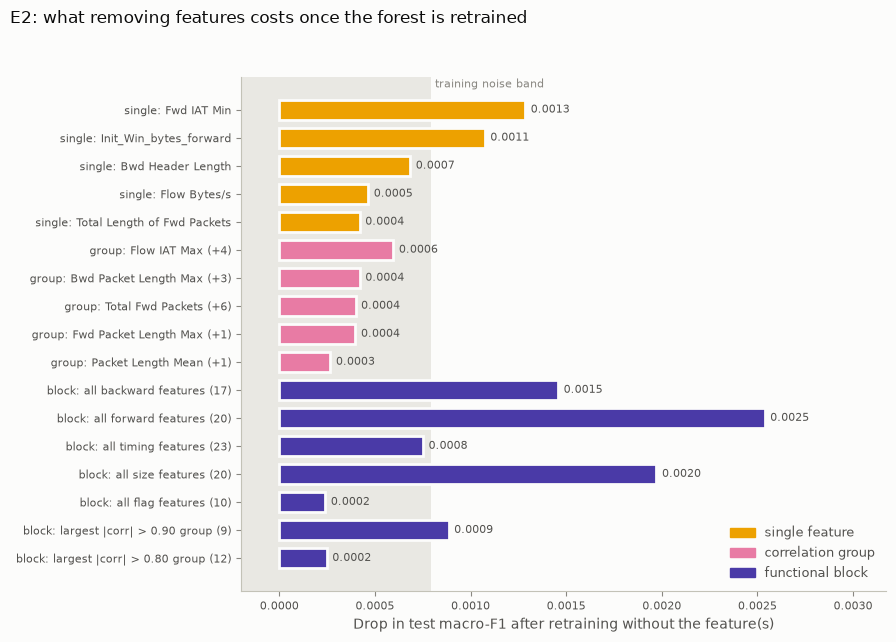

In [11]:
# STEP E2
# Figure: the cost of the largest single removals, the largest group removals and whole blocks, on one
# axis with the training-noise band. Kind is written in each label and every bar carries its value,
# so colour never carries the meaning alone.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
KIND_COLORS = {"single feature": "#eda100", "correlation group": "#e87ba4", "functional block": "#4a3aa7"}
bars = pd.concat([
    pd.DataFrame({"label": [f"single: {f}" for f in e2_single.index[:5]],
                  "drop": e2_single["macro_f1_drop"].iloc[:5].to_numpy(), "kind": "single feature"}),
    pd.DataFrame({"label": [f"group: {g}" for g in e2_group.index[:5]],
                  "drop": e2_group["macro_f1_drop"].iloc[:5].to_numpy(), "kind": "correlation group"}),
    pd.DataFrame({"label": [f"block: {b} ({n})" for b, n in e2_blocks["features_removed"].items()],
                  "drop": e2_blocks["macro_f1_drop"].to_numpy(), "kind": "functional block"}),
]).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.axvspan(-band, band, color=GRID, alpha=0.7, linewidth=0)
ax.text(band, len(bars) - 0.3, " training noise band", color=MUTED, fontsize=8, va="bottom")
ax.barh(bars.index, bars["drop"], color=bars["kind"].map(KIND_COLORS), height=0.7,
        edgecolor=SURFACE, linewidth=2)
for y, d in zip(bars.index, bars["drop"]):
    ax.annotate(f"{d:.4f}", (max(d, 0), y), xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=8, color=INK_2)
ax.set_yticks(bars.index, bars["label"])
ax.tick_params(colors=MUTED, labelcolor=INK_2, labelsize=8)
ax.set_xlim(min(0, bars["drop"].min()) - 0.0002, bars["drop"].max() * 1.25)
ax.set_xlabel("Drop in test macro-F1 after retraining without the feature(s)", color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in KIND_COLORS.values()]
ax.legend(handles, list(KIND_COLORS), loc="lower right", frameon=False, labelcolor=INK_2, fontsize=9)
fig.suptitle("E2: what removing features costs once the forest is retrained", color=INK, x=0.01,
             ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("results/figures/E2_single_vs_group.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP E2 -->
**What we found.** Training randomness alone moves the macro-F1 of this forest by **0.0008** (6 seeds,
0.9936–0.9944), so smaller differences mean nothing.

- **Single removals look free**, as the lab expects: only 2 of the 68 cost more than the noise band,
  and the largest drop is 0.0013 (`Fwd IAT Min`), then 0.0011 (`Init_Win_bytes_forward`).
- **Group removals also look free**, which the lab does *not* expect: removing any of the 14
  correlation groups costs at most 0.0006, inside the noise band. Even SHAP's top family
  (`Bwd Packet Length Max/Mean/Std`, `Avg Bwd Segment Size`) costs only 0.0004.
- **Even whole blocks barely matter:** without all 20 forward features the macro-F1 drops by 0.0025,
  without all 20 size features by 0.0020, without all 17 backward features by 0.0015, and without all
  23 timing features by 0.0008.

So the redundancy in this feature set goes far beyond the 0.95 twin groups: the attacks in this data
can be recognised from several largely independent sets of features, and a retrained forest simply
switches to another set. This does **not** contradict F1. There, the twin family was replaced at
*prediction time* in a model that had learned to rely on it, and the attack probability fell by 0.47.
Here the forest is *retrained* without it and learns to rely on something else. Missing at prediction
time (a broken sensor, X1 and F1) and never collected (retraining, E2) are very different situations.

**Check yourself: the single test said a feature was expendable, the group test said its information
was essential. Which answer do you give an engineer deciding what to stop collecting?** The group answer,
because a field is never removed alone, but on our data even that answer is "cheap", so we would add
three conditions that macro-F1 does not show:

1. **Only with retraining.** A deployed model loses almost all its recall if a block it relies on
   disappears (X1: all backward fields missing → recall 0.001). Stop collecting a field only together
   with retraining and re-testing the model.
2. **Check what the remaining features are.** The backward features cost only 0.0015 macro-F1, but they
   are exactly the evidence the attacker cannot forge (D1: all ten SHAP top features are backward or
   mixed). A model retrained on forward-only features would rely entirely on features the attacker
   controls, so it would score almost the same on this test set and be far easier to evade. The cost
   of removing a field is a security cost as well as an accuracy cost.
3. **Remove groups, never judge single fields.** The single test would declare almost every field
   expendable, one at a time; removing many "expendable" fields together is exactly what the group and
   block tests show to be the real question.

<!-- STEP F1 -->
## Part F: Are the explanations honest?

A SHAP chart looks convincing whether or not it is right, so it has to be tested. Three checks: the
deletion test (F1), whether the numbers add up (F2), and how well LIME fits (F3).

### Step F1: The deletion test, alone and in groups

**Faithful** means the explanation describes what the model actually did. If SHAP says a feature
pushed a flow towards "attack", replacing that feature with an ordinary value (the training median)
should lower the attack probability, and clearly more than replacing the same number of *random*
features. The gap between the two is the **fidelity**.

We use the same 50 detected attacks as the attack in C2 and the ensemble in E1 (`ATTACK_IDX`, forest
probability 1.000 for all of them). For each flow we rank the features by their **signed** SHAP value
for the attack class (`np.argsort(-shap_row)[:k]`), so "top" means "pushed hardest towards attack".

- **Top-k vs random-k** (k = 1, 3, 5): replace the k top features, or k random features (averaged over
  10 random draws per flow), with training medians. This measures *fidelity*.
- **Single vs group**: replace the top feature alone, then the top feature **together with every
  feature correlated with it above 0.95** (its twins). This measures *redundancy* (lab section 3.6).

In [12]:
# STEP F1
f1_flows = X_test.iloc[ATTACK_IDX]
f1_shap = shap.TreeExplainer(rf)(f1_flows).values[:, :, 1]       # 50 x 68, attack class
f1_p0 = rf.predict_proba(f1_flows)[:, 1]
f1_base = f1_flows.to_numpy(dtype=float)
MEDIANS = TRAIN_MEDIAN[FEATURES].to_numpy()


def prob_after_replacing(columns_per_flow):
    """Forest probability after setting the given columns of each flow to the training median."""
    edited = f1_base.copy()                                       # never edit X_test itself
    for i, cols in enumerate(columns_per_flow):
        edited[i, cols] = MEDIANS[cols]
    return rf.predict_proba(pd.DataFrame(edited, columns=FEATURES))[:, 1]


top_order = np.argsort(-f1_shap, axis=1)                         # per flow, most "attack" first
f1_rng = np.random.default_rng(SEED)
N_DRAWS = 10
rows = []
for k in (1, 3, 5):
    p_top = prob_after_replacing([top_order[i, :k] for i in range(len(f1_flows))])
    p_rand = np.mean([prob_after_replacing([f1_rng.choice(len(FEATURES), k, replace=False)
                                            for _ in range(len(f1_flows))])
                      for _ in range(N_DRAWS)], axis=0)
    rows.append({"k": k,
                 "mean drop, SHAP top-k": (f1_p0 - p_top).mean(),
                 "mean drop, random-k": (f1_p0 - p_rand).mean(),
                 "fidelity gap": (f1_p0 - p_top).mean() - (f1_p0 - p_rand).mean(),
                 "flows below 0.5 after top-k": int((p_top < 0.5).sum())})
f1_topk = pd.DataFrame(rows).set_index("k")
f1_topk.round(4)

,"mean drop, SHAP top-k","mean drop, random-k",fidelity gap,flows below 0.5 after top-k
k,,,,
1,0.2008,0.0278,0.1730,0
3,0.4270,0.0941,0.3329,10
5,0.5432,0.1496,0.3936,30


In [13]:
# STEP F1
# Single vs group: the top feature alone, then the top feature plus all its twins (|corr| > 0.95).
top1 = [FEATURES[top_order[i, 0]] for i in range(len(f1_flows))]
twin_sets = [[f] + [t for t in CORR.index[CORR[f] > 0.95] if t != f] for f in top1]
p_single = prob_after_replacing([[j] for j in top_order[:, 0]])
p_group = prob_after_replacing([[FEATURES.index(t) for t in s] for s in twin_sets])

# The lab's group = direct twins of the top feature. Twins of twins also carry the same information
# (T4's chained groups), so we also replace the whole chained family.
from scipy.sparse.csgraph import connected_components
_linked = (CORR > 0.95).to_numpy(copy=True)   # pandas 3 may return a read-only view
np.fill_diagonal(_linked, False)
_, family_id = connected_components(_linked, directed=False)
family_sets = [[t for t in FEATURES if family_id[FEATURES.index(t)] == family_id[FEATURES.index(f)]]
               for f in top1]
p_family = prob_after_replacing([[FEATURES.index(t) for t in s] for s in family_sets])

f1_group = pd.DataFrame({"attack_type": type_test.iloc[ATTACK_IDX].to_numpy(),
                         "top_feature": top1, "group_size": [len(s) for s in twin_sets],
                         "family_size": [len(s) for s in family_sets],
                         "drop_single": f1_p0 - p_single, "drop_group": f1_p0 - p_group,
                         "drop_family": f1_p0 - p_family},
                        index=pd.Index(ATTACK_IDX, name="test_position"))
print("Top-ranked feature per flow (how often), and the size of its twin group:")
print(f1_group.groupby("top_feature").agg(flows=("group_size", "size"), direct_twins_group=("group_size", "first"),
                                          chained_family=("family_size", "first"))
      .sort_values("flows", ascending=False).to_string())

has_twins = f1_group["group_size"] > 1
summary_group = pd.DataFrame({
    "flows": [len(f1_group), int(has_twins.sum())],
    "mean drop, top-1 alone": [f1_group["drop_single"].mean(), f1_group.loc[has_twins, "drop_single"].mean()],
    "mean drop, top-1 + twins": [f1_group["drop_group"].mean(), f1_group.loc[has_twins, "drop_group"].mean()],
    "mean drop, top-1 + chained family": [f1_group["drop_family"].mean(), f1_group.loc[has_twins, "drop_family"].mean()],
    "below 0.5 alone": [int((p_single < 0.5).sum()), int((p_single[has_twins.to_numpy()] < 0.5).sum())],
    "below 0.5 with twins": [int((p_group < 0.5).sum()), int((p_group[has_twins.to_numpy()] < 0.5).sum())],
    "below 0.5 with family": [int((p_family < 0.5).sum()), int((p_family[has_twins.to_numpy()] < 0.5).sum())],
}, index=["all 50 flows", "flows whose top feature has twins"])

f1_table = pd.concat({"top-k vs random-k": f1_topk.reset_index().astype({"k": str}).set_index("k"),
                      "single vs group": summary_group})
f1_table.to_csv("results/tables/F1_deletion.csv", float_format="%.4f")
f1_group.to_csv("results/tables/F1_deletion_per_flow.csv", float_format="%.4f")
summary_group.round(4)

Top-ranked feature per flow (how often), and the size of its twin group:
                       flows  direct_twins_group  chained_family
top_feature                                                     
Bwd Packet Length Std     39                   2               4
Bwd Packets/s              7                   1               1
Idle Min                   2                   4               5
Bwd Header Length          1                   3               3
FIN Flag Count             1                   1               1


,flows,"mean drop, top-1 alone","mean drop, top-1 + twins","mean drop, top-1 + chained family",below 0.5 alone,below 0.5 with twins,below 0.5 with family
all 50 flows,50,0.2008,0.2469,0.4380,0,2,11
flows whose top feature has twins,42,0.1923,0.2471,0.4747,0,2,11


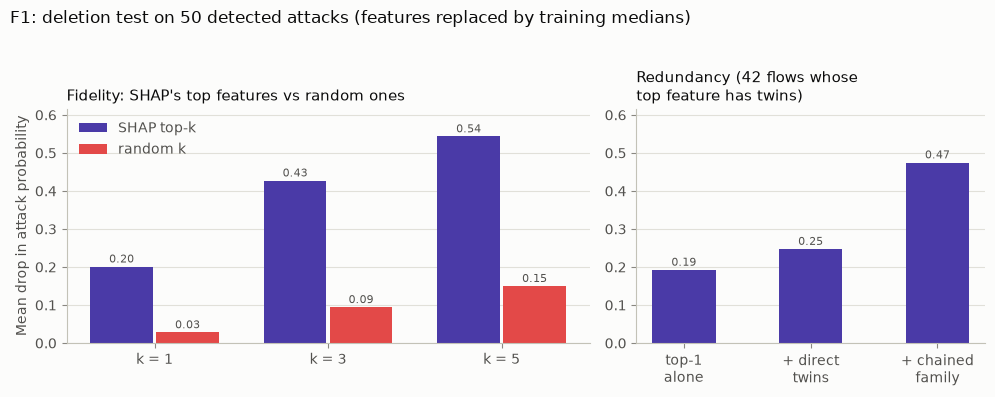

In [14]:
# STEP F1
# Figure: left, top-k vs random-k; right, top-1 alone vs top-1 with its twins.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SHAP_COLOR, RANDOM_COLOR = "#4a3aa7", "#e34948"


def plain_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


def label_bars(ax, bars):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=INK_2)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=SURFACE,
                               gridspec_kw={"width_ratios": [3, 2]})
plain_axes(ax1); plain_axes(ax2)
x = np.arange(3)
w = 0.36
b1 = ax1.bar(x - w / 2 - 0.01, f1_topk["mean drop, SHAP top-k"], w, color=SHAP_COLOR, label="SHAP top-k")
b2 = ax1.bar(x + w / 2 + 0.01, f1_topk["mean drop, random-k"], w, color=RANDOM_COLOR, label="random k")
label_bars(ax1, b1); label_bars(ax1, b2)
ax1.set_xticks(x, [f"k = {k}" for k in f1_topk.index])
ax1.set_ylabel("Mean drop in attack probability", color=INK_2)
ax1.set_title("Fidelity: SHAP's top features vs random ones", color=INK, loc="left", fontsize=11)
ax1.legend(frameon=False, labelcolor=INK_2, loc="upper left")

vals = summary_group.loc["flows whose top feature has twins",
                         ["mean drop, top-1 alone", "mean drop, top-1 + twins", "mean drop, top-1 + chained family"]]
b3 = ax2.bar([0, 1, 2], vals.to_numpy(), 0.5, color=SHAP_COLOR)
label_bars(ax2, b3)
ax2.set_xticks([0, 1, 2], ["top-1\nalone", "+ direct\ntwins", "+ chained\nfamily"])
ax2.set_title(f"Redundancy ({int(has_twins.sum())} flows whose\ntop feature has twins)", color=INK,
              loc="left", fontsize=11)
top = max(ax1.get_ylim()[1], ax2.get_ylim()[1]) * 1.08
ax1.set_ylim(0, top); ax2.set_ylim(0, top)
fig.suptitle("F1: deletion test on 50 detected attacks (features replaced by training medians)",
             color=INK, x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("results/figures/F1_deletion.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP F1 -->
**What we found: SHAP's ranking is faithful.** Replacing the features SHAP ranks highest lowers the
attack probability far more than replacing random features:

| k | Mean drop, SHAP top-k | Mean drop, random k | Fidelity gap | Flows pushed below 0.5 |
|---|---|---|---|---|
| 1 | 0.20 | 0.03 | 0.17 | 0 of 50 |
| 3 | 0.43 | 0.09 | 0.33 | 10 of 50 |
| 5 | 0.54 | 0.15 | 0.39 | 30 of 50 |

The top feature alone does 7 times as much as a random one, and the top five push 30 of the 50
attacks to "benign". So SHAP is pointing at features the forest really uses for these flows.

**Single vs group.** For 39 of the 50 flows the top feature is `Bwd Packet Length Std`. Its only
*direct* twin above 0.95 is one other feature, but through a chain it belongs to a family of four
(`Bwd Packet Length Max`, `Mean`, `Std` and `Avg Bwd Segment Size`, T4 group 6). For the 42 flows whose
top feature has twins:

| Replaced with medians | Mean drop | Flows below 0.5 |
|---|---|---|
| top feature alone | 0.19 | 0 |
| + its direct twins (the lab's group) | 0.25 | 2 |
| + its whole chained family | **0.47** | **11** |

The lab's group (direct twins) adds little, because most top features have only one direct twin. The
full family more than doubles the drop: the information sits in the family, not in any single member.

**Check yourself: removing the top feature alone barely moved the score, but the group did. Was SHAP
wrong, or the test?** The test. SHAP was right that the information in `Bwd Packet Length Std` matters
(the group drop proves it), but that information is shared with three twins. Removing one member
leaves the other three, so the forest still sees almost the same evidence and the probability barely
moves (none of the 50 flows crosses 0.5). A single-feature deletion test measures what a feature adds
*on top of* its twins, which is small when the twins are close copies; SHAP instead splits the credit
for the shared information among the twins. Both are correct answers to different questions. With
correlated features, a deletion test has to remove whole groups, otherwise it will wrongly suggest that
SHAP over-rates its top features. And how the group is defined matters: the lab's direct-twin group
understated the effect; the chained family showed it.

<!-- STEP F2 -->
### Step F2: Do the numbers add up?

SHAP is built so that **base value + sum of all SHAP values = the model's output** for that flow. For
TreeSHAP this holds by construction; checking it shows what the numbers actually *are*.

**Correction to the lab's hint.** The lab says TreeSHAP returns log-odds, to be put through
`1 / (1 + exp(-x))` before comparing with `predict_proba`. That is true for gradient boosting, but
**not for a scikit-learn random forest**: a forest's output is the average of its trees' class
shares, which is already a probability, so TreeSHAP explains the probability directly. For the forest
the sum must match `predict_proba` *without* a sigmoid. We show both, and extra X6 below checks
gradient boosting, where the sigmoid is needed.

In [15]:
# STEP F2
f2_explainer = shap.TreeExplainer(rf)
y_explain = y_test.iloc[EXPLAIN_IDX].to_numpy()
# Five flows from EXPLAIN_IDX: the first two attacks and the first three benign flows.
f2_pos = np.concatenate([EXPLAIN_IDX[y_explain == 1][:2], EXPLAIN_IDX[y_explain == 0][:3]])
f2_flows = X_test.iloc[f2_pos]
f2_sv = f2_explainer(f2_flows)

f2 = pd.DataFrame({
    "attack_type": type_test.iloc[f2_pos].to_numpy(),
    "base_value": f2_sv.base_values[:, 1],
    "sum_shap": f2_sv.values[:, :, 1].sum(axis=1),
}, index=pd.Index(f2_pos, name="test_position"))
f2["total"] = f2["base_value"] + f2["sum_shap"]
f2["predict_proba"] = rf.predict_proba(f2_flows)[:, 1]
f2["difference"] = (f2["total"] - f2["predict_proba"]).abs()
f2["sigmoid(total)  (lab hint, wrong here)"] = 1 / (1 + np.exp(-f2["total"]))

assert (f2["difference"] < 0.001).all(), "base value + SHAP does not match the forest's probability"
print(f"Largest difference: {f2['difference'].max():.2e} (must be below 0.001)")
f2.to_csv("results/tables/F2_additivity.csv", float_format="%.6f")
f2.round(4)

Largest difference: 4.44e-16 (must be below 0.001)


,attack_type,base_value,sum_shap,total,predict_proba,difference,"sigmoid(total) (lab hint, wrong here)"
test_position,,,,,,,
50280,DDoS,0.1507,0.8493,1.0,1.0,0.0,0.7311
44005,DoS Hulk,0.1507,0.8493,1.0,1.0,0.0,0.7311
12428,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000
72016,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000
53224,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000


<!-- STEP F2 -->
**What we found.** For all five flows, base value + SHAP sum equals the forest's attack probability to
within 5e-16 (rounding error), far inside the 0.001 the lab asks for. The forest is fully confident on
all five (probability exactly 1 for the two attacks, exactly 0 for the three benign flows), so the SHAP
values of an attack add up to +0.849 and those of a benign flow to −0.151. The base value (about 0.15) is the
forest's average attack probability over its training data, which is the attack rate. Each SHAP value
therefore says how many **percentage points of attack probability** a feature added or removed for
this flow. The column on the right shows what the lab's sigmoid hint would give: values squeezed
between 0.50 and 0.73, which match nothing. For a forest, the sigmoid is wrong.

**Check yourself: if the totals did not agree, what would that tell you about the explainer?** It would
mean the explainer is not describing the model we are scoring. The usual causes: the explanation is
in a different unit than we assume (log-odds vs probability, the very mistake the lab's hint invites);
the explainer was built for another model (e.g. a forest retrained after the explainer was created);
the explainer used an approximation (KernelSHAP or a sampled background) whose sum is only roughly
right; or the input was preprocessed differently for the explainer than for the model (scaled
vs raw). In all cases the per-feature numbers cannot be trusted, because they no longer add up to the
decision they claim to explain. TreeSHAP's exact additivity is what makes D1's and F1's numbers
meaningful as "percentage points of attack probability".

<!-- STEP F3 -->
### Step F3: How well does LIME fit?

LIME explains one flow by sampling thousands of slightly changed copies of it, asking the model about
each, and fitting a **straight line** (a weighted linear model) to the answers. Its explanation is the
slopes of that line. The slopes only mean something if the line fits the model well near the flow,
and LIME reports that fit as `exp.score`, an R² between 0 (useless) and 1 (perfect). Below about 0.70
the explanation should not be trusted much.

- LIME's statistics come from a **seeded 10,000-row sample of the training set** (much faster than
  all 267,984 rows, and enough to estimate each feature's quartiles).
- `discretize_continuous=True`: LIME works with ranges (quartiles) of each feature, because our
  features run from millions of bytes down to ratios near zero.
- **20 random test flows** (seed 42), as the lab asks. Because the forest is certain about almost
  every flow (probability exactly 0 or 1), we also explain **10 borderline test flows** with forest
  probability between 0.3 and 0.7, to answer whether the worst fits are the ones near 0.5.

In [16]:
# STEP F3
from lime.lime_tabular import LimeTabularExplainer

lime_rng = np.random.default_rng(SEED)
lime_background = X_train.to_numpy(dtype=float)[lime_rng.choice(len(X_train), 10_000, replace=False)]
lime_explainer = LimeTabularExplainer(lime_background, feature_names=FEATURES,
                                      class_names=["benign", "attack"],
                                      discretize_continuous=True, random_state=SEED)


def rf_predict_fn(a):
    """LIME passes numpy arrays; the forest was fitted on a DataFrame with named columns."""
    return rf.predict_proba(pd.DataFrame(a, columns=FEATURES))


random_pos = lime_rng.choice(len(X_test), 20, replace=False)
borderline_all = np.flatnonzero((rf_proba_test > 0.3) & (rf_proba_test < 0.7))
borderline_pos = lime_rng.choice(borderline_all, 10, replace=False)
print(f"{len(borderline_all)} test flows have forest probability between 0.3 and 0.7; 10 are explained")

start = time.time()
f3_rows = []
for group, positions in (("random", random_pos), ("borderline", borderline_pos)):
    for pos in positions:
        exp = lime_explainer.explain_instance(X_test.iloc[pos].to_numpy(dtype=float), rf_predict_fn,
                                              num_features=10)
        f3_rows.append({"group": group, "test_position": int(pos),
                        "attack_type": type_test.iloc[pos],
                        "forest_probability": rf_proba_test[pos],
                        "lime_r2": exp.score,
                        "lime_local_prediction": float(exp.local_pred[0]),
                        "top_feature": exp.as_list()[0][0]})
f3 = pd.DataFrame(f3_rows)
f3.to_csv("results/tables/F3_lime_fit.csv", index=False, float_format="%.4f")
print(f"LIME on {len(f3)} flows in {time.time() - start:.0f} s")

164 test flows have forest probability between 0.3 and 0.7; 10 are explained


LIME on 30 flows in 11 s


In [17]:
# STEP F3
rand = f3[f3["group"] == "random"]
worst = rand.loc[rand["lime_r2"].idxmin()]
print("20 random flows:")
print(rand[["test_position", "attack_type", "forest_probability", "lime_r2"]]
      .sort_values("lime_r2").round(3).to_string(index=False))
print(f"\nAttacks among them: {int((rand['attack_type'] != 'BENIGN').sum())} of 20")
print(f"Mean R² {rand['lime_r2'].mean():.3f}, minimum {rand['lime_r2'].min():.3f}, "
      f"{int((rand['lime_r2'] < 0.70).sum())} of 20 below 0.70")
print(f"Worst-fitting flow: position {int(worst['test_position'])} ({worst['attack_type']}), "
      f"forest probability {worst['forest_probability']:.3f}, R² {worst['lime_r2']:.3f}")

20 random flows:
 test_position attack_type  forest_probability  lime_r2
         75112      BENIGN               0.000    0.075
         59207      BENIGN               0.000    0.089
         14883      BENIGN               0.000    0.135
         68491      BENIGN               0.000    0.144
         19482      BENIGN               0.000    0.145
         35984      BENIGN               0.000    0.154
         83837    DoS Hulk               1.000    0.156
         58398      BENIGN               0.000    0.156
         39263      BENIGN               0.000    0.157
         61382      BENIGN               0.000    0.157
         69137      BENIGN               0.000    0.160
         46471      BENIGN               0.000    0.161
         18117      BENIGN               0.000    0.166
         57061      BENIGN               0.001    0.167
         62696      BENIGN               0.001    0.184
         58390      BENIGN               0.000    0.186
         72689      BENIGN     

In [18]:
# STEP F3
# Are the worst fits the flows near 0.5? Compare the two groups, and correlate R² with the distance
# of the forest's probability from 0.5.
from scipy.stats import spearmanr

summary = f3.groupby("group")["lime_r2"].agg(["count", "mean", "min", "max"])
summary["below 0.70"] = f3.assign(low=f3["lime_r2"] < 0.70).groupby("group")["low"].sum()
print(summary.round(3).to_string())
rho, pval = spearmanr(f3["lime_r2"], (f3["forest_probability"] - 0.5).abs())
print(f"\nSpearman(R², |probability - 0.5|) over all 30 flows: {rho:.3f} (p = {pval:.3f})")
print("\nBorderline flows:")
print(f3[f3["group"] == "borderline"][["attack_type", "forest_probability", "lime_r2",
                                         "lime_local_prediction"]].round(3).to_string(index=False))

            count   mean    min    max  below 0.70
group                                             
borderline     10  0.175  0.151  0.193          10
random         20  0.175  0.075  0.300          20

Spearman(R², |probability - 0.5|) over all 30 flows: -0.198 (p = 0.295)

Borderline flows:
attack_type  forest_probability  lime_r2  lime_local_prediction
     BENIGN               0.341    0.193                  0.244
   DoS Hulk               0.320    0.181                  0.263
   DoS Hulk               0.671    0.183                  0.271
        Bot               0.480    0.159                  0.262
   PortScan               0.439    0.151                  0.237
     BENIGN               0.551    0.187                  0.297
     BENIGN               0.419    0.171                  0.253
   DoS Hulk               0.580    0.172                  0.290
   DoS Hulk               0.340    0.172                  0.253
     BENIGN               0.604    0.184                  0.292


<!-- STEP F3 -->
**What we found.** LIME fits our forest **badly everywhere**. Over the 20 random flows (18 benign, 2 DoS
Hulk) the R² ranges from 0.075 to 0.300, with a **mean of 0.175**, and **all 20 are below 0.70**. The
worst fit (R² 0.075) is a benign flow the forest is certain about (probability 0.000). This is not a
setup error: Lab 3 ran LIME on a forest trained on the same CICIDS data and got the same picture (200
flows, mean R² 0.21, best 0.33, none above 0.70).

Why the straight line fits so badly: LIME builds its neighbourhood by drawing each feature
independently from the training quartiles, so most "neighbours" are unrealistic mixtures of flows. The
forest gives almost all of them a probability of 0 or 1, decided by sharp thresholds and interactions
between twin features. A weighted straight line over 68 "same quartile or not" indicators cannot follow
such a step-shaped surface. It does not even reproduce the forest's answer at the flow itself: for the
borderline flows LIME's line predicts 0.24–0.30 where the forest says 0.32–0.67.

**Check yourself: were the worst-fitting flows the ones near 0.5?** No. The worst fit is a flow with
probability 0.000, and the 10 borderline flows (probability 0.32–0.67) fit neither better nor worse
than the random ones (same mean R² 0.175, range 0.15–0.19). There is no clear link between the fit and
the distance from 0.5 (Spearman −0.20, p = 0.30). The expectation that borderline flows fit worst
assumes a model that is smooth elsewhere; our forest is not smooth anywhere, so LIME's line fits
poorly whether the flow is certain or borderline.

**Check yourself: which of the three checks could run automatically on every alert, and why?**

- **F3 (LIME fit)** is the most useful one to run on every alert: LIME computes `exp.score` anyway when
  it explains a flow, so the check is free. A rule such as "R² below 0.70 → show the explanation with a
  warning, or do not show it" can be applied to every alert. On our forest it would flag *every*
  LIME explanation, which is itself a finding: LIME should not be the explanation analysts see for this
  model.
- **F2 (additivity)** is also free and automatic (one sum per alert), but for TreeSHAP it holds by
  construction, so it only catches set-up errors (wrong model, wrong unit), not misleading explanations.
- **F1 (deletion test)** needs extra model calls per alert (the top-k features and a few random sets
  replaced by medians), so it is feasible per alert but costs more; it is better run regularly on a
  sample of alerts to monitor whether the explanations stay faithful.

In [19]:
# STANDIN E1
# Gradient boosting from step E1 (Track 2), loaded from the cache so this notebook runs on its own.
gb = joblib.load(MODEL_DIR / "gb.joblib")

<!-- STEP X6 -->
### Extra X6: the same check for gradient boosting

Gradient boosting adds up the outputs of its trees in **log-odds**, and turns the total into a
probability with the sigmoid at the very end. TreeSHAP explains the log-odds, and returns one value per
feature (no class axis), so here the lab's hint is exactly right.

In [20]:
# STEP X6
gb_sv = shap.TreeExplainer(gb)(f2_flows)
print("SHAP values shape for gradient boosting:", gb_sv.values.shape, "(no class axis)")
x6 = pd.DataFrame({
    "base_value (log-odds)": np.asarray(gb_sv.base_values).reshape(-1),
    "sum_shap (log-odds)": gb_sv.values.sum(axis=1),
}, index=f2.index)
x6["total (log-odds)"] = x6["base_value (log-odds)"] + x6["sum_shap (log-odds)"]
x6["sigmoid(total)"] = 1 / (1 + np.exp(-x6["total (log-odds)"]))
x6["predict_proba"] = gb.predict_proba(f2_flows)[:, 1]
x6["difference after sigmoid"] = (x6["sigmoid(total)"] - x6["predict_proba"]).abs()
x6["difference without sigmoid"] = (x6["total (log-odds)"] - x6["predict_proba"]).abs()
assert (x6["difference after sigmoid"] < 0.001).all()
x6.to_csv("results/tables/X6_gb_additivity.csv", float_format="%.6f")
x6.round(4)

SHAP values shape for gradient boosting: (5, 68) (no class axis)


,base_value (log-odds),sum_shap (log-odds),total (log-odds),sigmoid(total),predict_proba,difference after sigmoid,difference without sigmoid
test_position,,,,,,,
50280,-5.6059,13.7884,8.1825,0.9997,0.9997,0.0,7.1828
44005,-5.6059,12.6125,7.0066,0.9991,0.9991,0.0,6.0075
12428,-5.6059,-3.1032,-8.7091,0.0002,0.0002,0.0,8.7093
72016,-5.6059,-3.0729,-8.6787,0.0002,0.0002,0.0,8.6789
53224,-5.6059,-3.1032,-8.7091,0.0002,0.0002,0.0,8.7093


<!-- STEP X6 -->
For gradient boosting the totals are log-odds (large positive for attacks, large negative for benign
flows) and only match `predict_proba` after the sigmoid. So the unit of a SHAP value depends on the
model: percentage points of probability for our forest, log-odds for gradient boosting. Comparing SHAP
numbers across the two models without converting would be meaningless.